# Unsupervised Machine Learning: Clustering Financial Assets with K-Means and DBSCAN

## Learning Objectives

By the end of this notebook, you should be able to:

- Explain what unsupervised learning is.
- Define clustering and explain why it is useful.
- Engineer return and volatility features for financial assets.
- Explain why feature scaling is necessary.
- Use K-Means clustering to group similar assets.
- Use the elbow method and silhouette score to choose a reasonable number of K-Means clusters.
- Explain how DBSCAN works.
- Understand DBSCAN's `eps` and `min_samples` parameters.
- Identify assets that DBSCAN labels as noise.
- Visualize and compare K-Means and DBSCAN results.
- Interpret clusters as broad risk-return groups.
- Create a final report containing cluster labels and a short interpretation.

## Expected Output

The completed notebook should include:

- Cleaned historical price data.
- Daily returns for multiple assets.
- Engineered return and volatility features.
- Scaled features.
- K-Means cluster labels.
- DBSCAN cluster labels.
- K-Means and DBSCAN visualizations.
- A cluster summary table.
- A short interpretation write-up.

# 1. What Is Unsupervised Learning?

## Definition

**Unsupervised learning** is a type of machine learning where the algorithm is given input data without correct output labels.

The algorithm must discover patterns, similarities, groups, or unusual observations on its own.

Unlike supervised learning, there is no target column containing the correct answer.

## Supervised vs Unsupervised Learning

| Supervised Learning | Unsupervised Learning |
|---|---|
| Has labels | Has no labels |
| Predicts a known target | Discovers hidden structure |
| Examples: price prediction, fraud classification | Examples: clustering, anomaly detection |

## Key Idea

Supervised learning asks:

> What answer should we predict?

Unsupervised learning asks:

> What hidden structure exists in the data?

# 2. What Is Clustering?

## Definition

**Clustering** is an unsupervised learning task that groups observations so that items in the same cluster are more similar to each other than to items in other clusters.

Each group is called a **cluster**.

## Financial Example

Assets may form groups such as:

- Higher return and higher volatility.
- Lower return and lower volatility.
- Moderate return and moderate volatility.
- Unusual assets that do not fit any common group.

## Important Note

Cluster labels such as `0`, `1`, and `2` are arbitrary.

We must inspect the features before assigning meaning.

# 3. Why Cluster Financial Assets?

Clustering can help us:

- Identify assets with similar risk-return behavior.
- Separate lower-risk and higher-risk assets.
- Build diversified portfolios.
- Find alternatives to a preferred stock.
- Create groups for a recommendation system.
- Identify unusual assets.
- Understand broad market behavior.

## Limitation

Clustering does not predict which asset will perform best in the future.

It only groups assets according to historical features.

# 4. What Is a Feature?

## Definition

A **feature** is a measurable property used by a machine-learning algorithm.

For asset clustering:

- Each row represents one asset.
- Each column represents one financial feature.

## Why Feature Choice Matters

Clusters are based entirely on the selected features.

Using only volatility groups assets by risk.

Using return and volatility groups assets by both performance and risk.

> A clustering algorithm can only discover patterns in the information we provide.

# 5. Features Used in This Notebook

## Average Daily Return

**Definition:** The average percentage change in closing price from one trading day to the next.

## Daily Volatility

**Definition:** The standard deviation of daily returns.

Higher volatility means the asset's returns fluctuate more.

## Annualized Return

**Definition:** An estimate of yearly return based on average daily return.

```text
Annualized Return = Average Daily Return × 252
```

## Annualized Volatility

**Definition:** An estimate of yearly volatility based on daily volatility.

```text
Annualized Volatility = Daily Volatility × √252
```

There are approximately 252 trading days in a year.

## Optional Feature: Maximum Drawdown

**Definition:** The largest percentage decline from a previous peak to a later low.

This can be introduced as a bonus feature because it captures downside risk.

# 6. Why Raw Price Is Usually a Poor Clustering Feature

A higher stock price does not automatically mean:

- Higher return.
- Higher risk.
- Better company.
- More expensive valuation.

Raw price is affected by share structure and stock splits.

Return and volatility are more meaningful for comparing behavior across assets.

# 7. Import Libraries

In [ ]:
# Run only if needed:
# !pip install yfinance scikit-learn

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score, pairwise_distances
from sklearn.neighbors import NearestNeighbors

# 8. Select Assets

In [3]:
tickers = [
    "AAPL",
    "MSFT",
    "GOOG",
    "AMZN",
    "META",
    "NVDA",
    "TSLA",
    "JPM",
    "BAC",
    "KO",
    "PG",
    "XOM"
]

print("Number of assets:", len(tickers))
print(tickers)

Number of assets: 12
['AAPL', 'MSFT', 'GOOG', 'AMZN', 'META', 'NVDA', 'TSLA', 'JPM', 'BAC', 'KO', 'PG', 'XOM']


The list includes assets from different sectors and risk profiles.

# 9. Download Historical Data

In [4]:
data = yf.download(
    tickers,
    start="2023-01-01",
    end="2025-01-01",
    progress=True,
    auto_adjust=False
)

data.head()

[*********************100%***********************]  12 of 12 completed


Price        Adj Close                                               \
Ticker            AAPL       AMZN        BAC       GOOG         JPM   
Date                                                                  
2023-01-03  122.876747  85.820000  30.640945  88.916039  123.735207   
2023-01-04  124.144135  85.139999  31.217010  87.934700  124.889023   
2023-01-05  122.827606  83.120003  31.153000  86.011650  124.861343   
2023-01-06  127.346924  86.080002  31.463888  87.389511  127.250671   
2023-01-09  127.867638  87.360001  30.988407  88.023933  126.724823   

Price                                                                 ...  \
Ticker             KO        META        MSFT       NVDA          PG  ...   
Date                                                                  ...   
2023-01-03  56.759892  123.654114  232.510544  14.283262  137.454971  ...   
2023-01-04  56.732841  126.261223  222.339828  14.716300  138.053528  ...   
2023-01-05  56.083645  125.834976  215.750153  14.233374  136.339508  ...   
2023-01-06  57.165646  128.888153  218.292847  14.826057  139.586121  ...   
2023-01-09  56.453320  128.342957  220.418198  15.593353  137.881149  ...   

Price         Volume                                                    \
Ticker           BAC      GOOG       JPM        KO      META      MSFT   
Date                                                                     
2023-01-03  35221500  20738500  11054800  12180500  35528500  25740000   
2023-01-04  41998500  27046500  11687600  13387900  32397100  50623400   
2023-01-05  34177000  23136100   8381300   9814700  25447100  39585600   
2023-01-06  34068700  26612600  10029100   9990000  27584500  43613600   
2023-01-09  43818800  22996700   8482300   9442600  26649100  27369800   

Price                                                
Ticker           NVDA       PG       TSLA       XOM  
Date                                                 
2023-01-03  401277000  6447300  231402800  15146200  
2023-01-04  431324000  7313400  180389000  18058400  
2023-01-05  389168000  5373800  157986300  15946600  
2023-01-06  405044000  7882200  220911100  16348100  
2023-01-09  504231000  5727000  190284000  17964600  

[5 rows x 72 columns]

## Extract Closing Prices

In [5]:
if isinstance(data.columns, pd.MultiIndex):
    prices = data["Close"].copy()
else:
    prices = data.copy()

prices.head()

Ticker,AAPL,AMZN,BAC,GOOG,JPM,KO,META,MSFT,NVDA,PG,TSLA,XOM
Date,,,,,,,,,,,,
2023-01-03,125.070000,85.820000,33.509998,89.699997,135.119995,62.950001,124.739998,239.580002,14.315,151.570007,108.099998,106.510002
2023-01-04,126.360001,85.139999,34.139999,88.709999,136.380005,62.919998,127.370003,229.100006,14.749,152.229996,113.639999,106.820000
2023-01-05,125.019997,83.120003,34.070000,86.769997,135.350006,62.200001,126.940002,222.309998,14.265,150.339996,110.339996,109.209999
2023-01-06,129.619995,86.080002,34.410000,88.160004,137.940002,63.400002,130.020004,224.929993,14.859,153.919998,113.059998,110.529999
2023-01-09,130.149994,87.360001,33.889999,88.800003,137.369995,62.610001,129.470001,227.119995,15.628,152.039993,119.769997,108.470001


## Inspect the Data

In [6]:
print("Shape:", prices.shape)
print("Columns:", prices.columns.tolist())

print("\nMissing values:")
print(prices.isna().sum())

Shape: (502, 12)
Columns: ['AAPL', 'AMZN', 'BAC', 'GOOG', 'JPM', 'KO', 'META', 'MSFT', 'NVDA', 'PG', 'TSLA', 'XOM']

Missing values:
Ticker
AAPL    0
AMZN    0
BAC     0
GOOG    0
JPM     0
KO      0
META    0
MSFT    0
NVDA    0
PG      0
TSLA    0
XOM     0
dtype: int64


# 10. Clean the Data

## Why Missing Values May Appear

Missing values may occur because of:

- Different listing dates.
- Market holidays.
- Download errors.
- Suspended trading.
- Delisted assets.

## Cleaning Strategy

1. Sort by date.
2. Forward-fill small gaps.
3. Drop remaining missing rows.

Forward fill should not be used blindly for long missing periods.

In [7]:
prices = prices.sort_index()
prices = prices.ffill()
prices = prices.dropna()

print(prices.isna().sum())
print("Cleaned shape:", prices.shape)

Ticker
AAPL    0
AMZN    0
BAC     0
GOOG    0
JPM     0
KO      0
META    0
MSFT    0
NVDA    0
PG      0
TSLA    0
XOM     0
dtype: int64
Cleaned shape: (502, 12)


# 11. Calculate Daily Returns

In [8]:
daily_returns = prices.pct_change()
daily_returns = daily_returns.dropna()

daily_returns.head()

Ticker,AAPL,AMZN,BAC,GOOG,JPM,KO,META,MSFT,NVDA,PG,TSLA,XOM
Date,,,,,,,,,,,,
2023-01-04,0.010314,-0.007924,0.018800,-0.011037,0.009325,-0.000477,0.021084,-0.043743,0.030318,0.004354,0.051249,0.002911
2023-01-05,-0.010605,-0.023726,-0.002050,-0.021869,-0.007552,-0.011443,-0.003376,-0.029638,-0.032816,-0.012415,-0.029039,0.022374
2023-01-06,0.036794,0.035611,0.009979,0.016019,0.019136,0.019293,0.024263,0.011785,0.041640,0.023813,0.024651,0.012087
2023-01-09,0.004089,0.014870,-0.015112,0.007260,-0.004132,-0.012461,-0.004230,0.009736,0.051753,-0.012214,0.059349,-0.018637
2023-01-10,0.004456,0.028732,0.006787,0.004955,0.008954,-0.007666,0.027188,0.007617,0.017981,-0.000987,-0.007681,0.014935


## Interpretation

A return of `0.02` means `2%`.

A return of `-0.015` means `-1.5%`.

In [8]:
daily_returns.describe()

Ticker,AAPL,AMZN,BAC,GOOG,JPM,KO,META,MSFT,NVDA,PG,TSLA,XOM
count,501.000000,501.000000,501.000000,501.000000,501.000000,501.000000,501.000000,501.000000,501.000000,501.000000,501.000000,501.000000
mean,0.001477,0.002061,0.000664,0.001672,0.001242,0.000012,0.003367,0.001230,0.004970,0.000246,0.003297,0.000118
std,0.013451,0.019290,0.015696,0.018376,0.013977,0.008231,0.024055,0.014282,0.031805,0.009466,0.036730,0.014054
min,-0.048167,-0.087847,-0.062039,-0.095989,-0.064678,-0.048328,-0.105613,-0.060528,-0.100046,-0.048432,-0.123346,-0.049748
25%,-0.006625,-0.008877,-0.008197,-0.009119,-0.005454,-0.004963,-0.008364,-0.006807,-0.014468,-0.005240,-0.017797,-0.008719
50%,0.001632,0.000909,-0.000240,0.003143,0.001863,0.000331,0.001372,0.001343,0.004156,0.000403,0.001871,-0.000095
75%,0.008986,0.013440,0.008585,0.011232,0.008124,0.004330,0.013771,0.009736,0.022457,0.005515,0.021729,0.008873
max,0.072649,0.082693,0.084288,0.099652,0.115445,0.028846,0.232824,0.072435,0.243696,0.041390,0.219190,0.059000


# 12. Engineer Asset-Level Features

The clustering algorithm needs one row per asset.

In [9]:
feature_table = pd.DataFrame({
    "AverageDailyReturn": daily_returns.mean(),
    "DailyVolatility": daily_returns.std()
})

feature_table["AnnualizedReturn"] = (
    feature_table["AverageDailyReturn"] * 252
)

feature_table["AnnualizedVolatility"] = (
    feature_table["DailyVolatility"] * np.sqrt(252)
)

feature_table

,AverageDailyReturn,DailyVolatility,AnnualizedReturn,AnnualizedVolatility
Ticker,,,,
AAPL,0.001477,0.013451,0.372128,0.213524
AMZN,0.002061,0.019290,0.519251,0.306214
BAC,0.000664,0.015696,0.167295,0.249167
GOOG,0.001672,0.018376,0.421457,0.291708
JPM,0.001242,0.013977,0.312937,0.221885
KO,0.000012,0.008231,0.002992,0.130659
META,0.003367,0.024055,0.848523,0.381857
MSFT,0.001230,0.014282,0.309952,0.226726
NVDA,0.004970,0.031805,1.252452,0.504883


## Features Used for Clustering

In [10]:
features = feature_table[
    ["AnnualizedReturn", "AnnualizedVolatility"]
].copy()

features

,AnnualizedReturn,AnnualizedVolatility
Ticker,,
AAPL,0.372128,0.213524
AMZN,0.519251,0.306214
BAC,0.167295,0.249167
GOOG,0.421457,0.291708
JPM,0.312937,0.221885
KO,0.002992,0.130659
META,0.848523,0.381857
MSFT,0.309952,0.226726
NVDA,1.252452,0.504883


# 13. Visualize the Raw Features

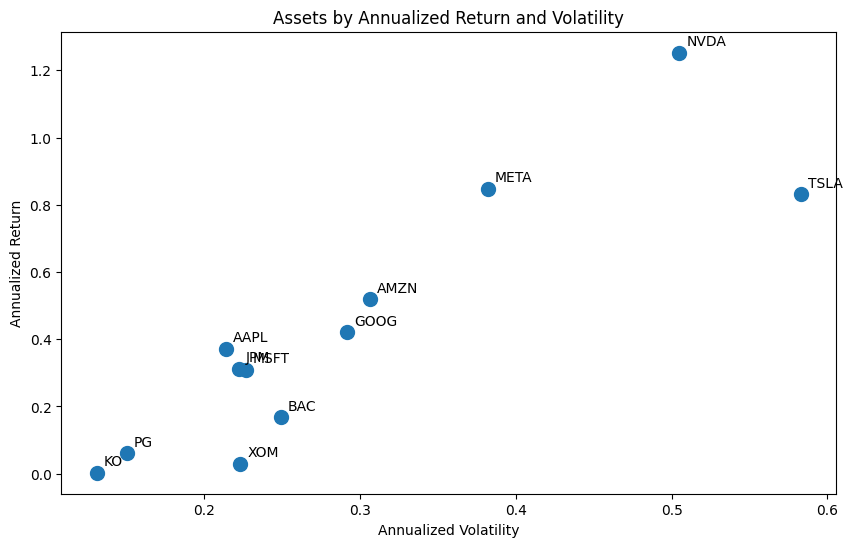

In [11]:
plt.figure(figsize=(10, 6))

plt.scatter(
    features["AnnualizedVolatility"],
    features["AnnualizedReturn"],
    s=100
)

for ticker, row in features.iterrows():
    plt.annotate(
        ticker,
        (
            row["AnnualizedVolatility"],
            row["AnnualizedReturn"]
        ),
        xytext=(5, 5),
        textcoords="offset points"
    )

plt.title("Assets by Annualized Return and Volatility")
plt.xlabel("Annualized Volatility")
plt.ylabel("Annualized Return")
plt.show()

## Questions

- Which asset has the highest volatility?
- Which asset has the highest return?
- Do any natural groups appear?
- Are any assets far from the rest?

# 14. What Is Feature Scaling?

## Definition

**Feature scaling** transforms numerical features so they are measured on comparable scales.

## Why It Matters

K-Means and DBSCAN both use distance.

A feature with larger numerical values can dominate the result.

## Standardization

Standardization transforms each feature to approximately:

- Mean = 0
- Standard deviation = 1

```text
Scaled Value = (Value - Mean) / Standard Deviation
```

In [17]:
scaler = StandardScaler()

scaled_features = scaler.fit_transform(features)

scaled_features_df = pd.DataFrame(
    scaled_features,
    index=features.index,
    columns=features.columns
)

scaled_features_df.head()

,AnnualizedReturn,AnnualizedVolatility
Ticker,,
AAPL,-0.151639,-0.585185
AMZN,0.251442,0.121714
BAC,-0.712828,-0.313352
GOOG,-0.016489,0.011087
JPM,-0.313807,-0.521420


# 15. Why Use More Than One Clustering Algorithm?

Different clustering algorithms define groups differently.

## K-Means

K-Means groups points according to distance from a shared center.

## DBSCAN

DBSCAN groups points according to dense neighborhoods.

## Main Difference

```text
K-Means:
“How close is this asset to a cluster center?”

DBSCAN:
“Does this asset belong to a dense neighborhood?”
```

Using both methods allows us to compare:

- Complete grouping.
- Density-based grouping.
- Outlier detection.
- Sensitivity to assumptions.

# 16. What Is K-Means?

## Definition

**K-Means** is a centroid-based clustering algorithm that divides observations into a predefined number of groups.

Each cluster center is called a **centroid**.

## How It Works

1. Choose the number of clusters, `K`.
2. Select initial centroids.
3. Assign each asset to its nearest centroid.
4. Recalculate the centroids.
5. Repeat until assignments stabilize.

## Main Parameters

- `n_clusters`: number of groups to create.
- `random_state`: makes results reproducible.
- `n_init`: runs K-Means multiple times and keeps the best result.

# 17. Choose K with the Elbow Method

## Inertia

**Inertia** is the total squared distance between observations and their assigned centroids.

Lower inertia means points are closer to their cluster centers.

We look for a point where improvement begins to slow down.

In [12]:
inertias = []
k_values = range(1, 7)

for k in k_values:
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    model.fit(scaled_features)
    inertias.append(model.inertia_)

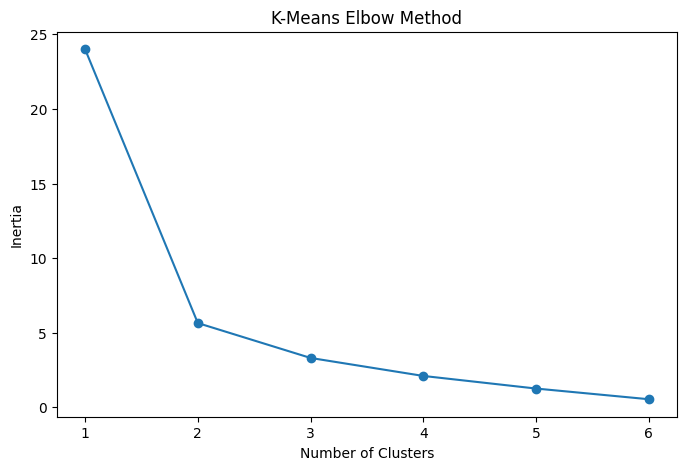

In [13]:
plt.figure(figsize=(8, 5))
plt.plot(k_values, inertias, marker="o")
plt.title("K-Means Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.show()

# 18. Use Silhouette Score

## Definition

The **silhouette score** measures how well each observation fits its own cluster compared with other clusters.

Typical interpretation:

- Close to `1`: well separated.
- Close to `0`: overlapping clusters.
- Below `0`: possibly assigned poorly.

In [19]:
silhouette_results = []

for k in range(2, 7):
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = model.fit_predict(scaled_features)

    score = silhouette_score(
        scaled_features,
        labels
    )

    silhouette_results.append({
        "K": k,
        "SilhouetteScore": score
    })

silhouette_table = pd.DataFrame(silhouette_results)
silhouette_table

,K,SilhouetteScore
0,2,0.643534
1,3,0.474622
2,4,0.372466
3,5,0.351001
4,6,0.395165


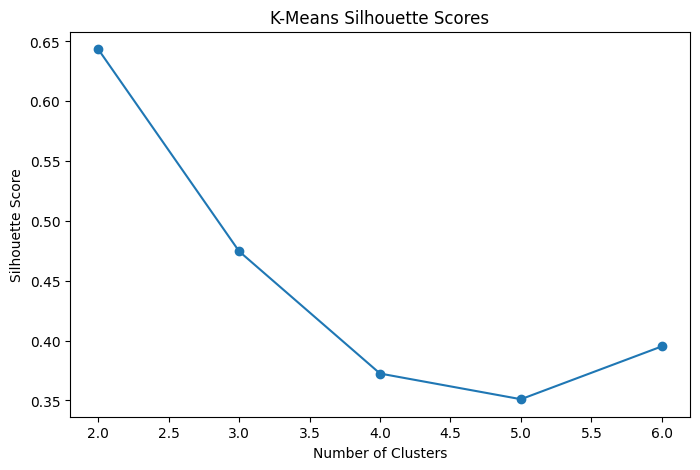

In [15]:
plt.figure(figsize=(8, 5))
plt.plot(
    silhouette_table["K"],
    silhouette_table["SilhouetteScore"],
    marker="o"
)
plt.title("K-Means Silhouette Scores")
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.show()

# 19. Fit the Final K-Means Model

In [20]:
chosen_k = 2

kmeans = KMeans(
    n_clusters=chosen_k,
    random_state=42,
    n_init=10
)

kmeans_labels = kmeans.fit_predict(
    scaled_features
)

clustered_assets = feature_table.copy()
clustered_assets["KMeansCluster"] = kmeans_labels

clustered_assets

,AverageDailyReturn,DailyVolatility,AnnualizedReturn,AnnualizedVolatility,KMeansCluster
Ticker,,,,,
AAPL,0.001477,0.013451,0.372128,0.213524,0
AMZN,0.002061,0.019290,0.519251,0.306214,0
BAC,0.000664,0.015696,0.167295,0.249167,0
GOOG,0.001672,0.018376,0.421457,0.291708,0
JPM,0.001242,0.013977,0.312937,0.221885,0
KO,0.000012,0.008231,0.002992,0.130659,0
META,0.003367,0.024055,0.848523,0.381857,1
MSFT,0.001230,0.014282,0.309952,0.226726,0
NVDA,0.004970,0.031805,1.252452,0.504883,1


# 20. Visualize K-Means Clusters

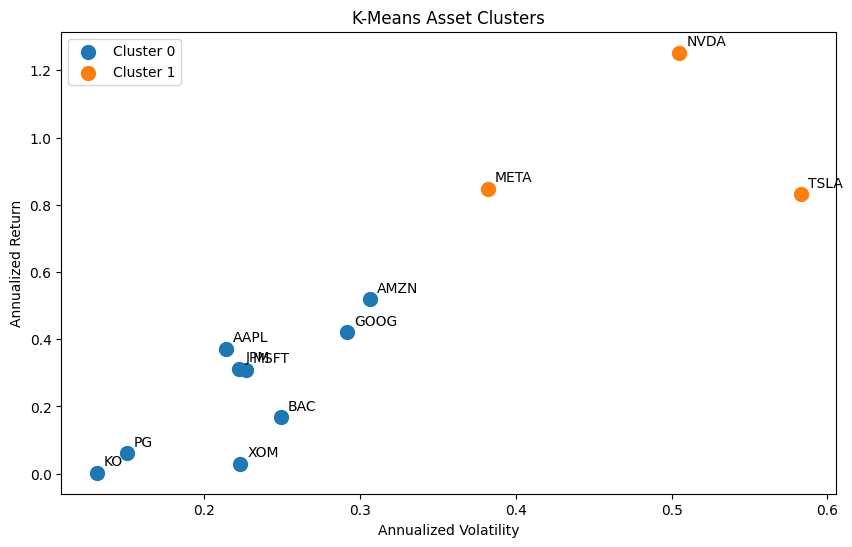

In [21]:
plt.figure(figsize=(10, 6))

for cluster_id in sorted(
    clustered_assets["KMeansCluster"].unique()
):
    subset = clustered_assets[
        clustered_assets["KMeansCluster"] == cluster_id
    ]

    plt.scatter(
        subset["AnnualizedVolatility"],
        subset["AnnualizedReturn"],
        label=f"Cluster {cluster_id}",
        s=100
    )

for ticker, row in clustered_assets.iterrows():
    plt.annotate(
        ticker,
        (
            row["AnnualizedVolatility"],
            row["AnnualizedReturn"]
        ),
        xytext=(5, 5),
        textcoords="offset points"
    )

plt.title("K-Means Asset Clusters")
plt.xlabel("Annualized Volatility")
plt.ylabel("Annualized Return")
plt.legend()
plt.show()

# 21. Display K-Means Centroids

In [22]:
kmeans_centers_original = scaler.inverse_transform(
    kmeans.cluster_centers_
)

kmeans_centers = pd.DataFrame(
    kmeans_centers_original,
    columns=[
        "AnnualizedReturn",
        "AnnualizedVolatility"
    ]
)

kmeans_centers.index.name = "Cluster"
kmeans_centers

,AnnualizedReturn,AnnualizedVolatility
Cluster,,
0,0.244202,0.223694
1,0.977297,0.489935


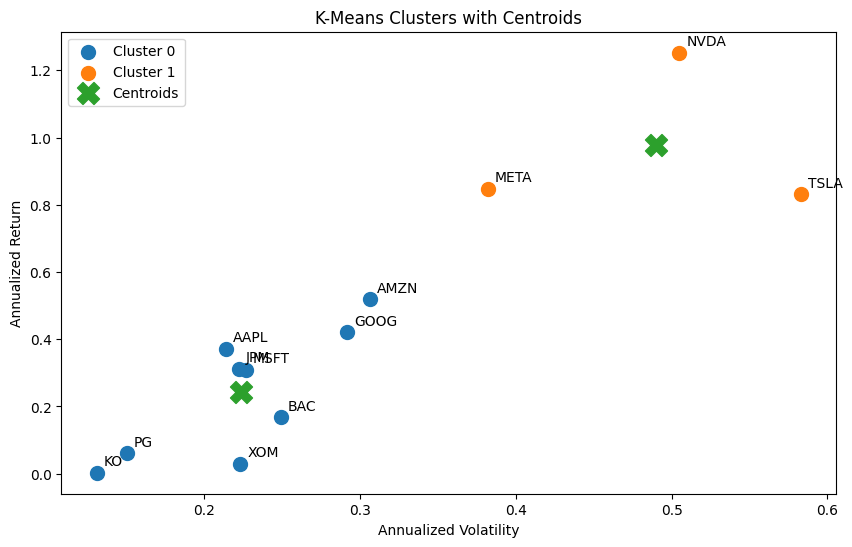

In [23]:
plt.figure(figsize=(10, 6))

for cluster_id in sorted(
    clustered_assets["KMeansCluster"].unique()
):
    subset = clustered_assets[
        clustered_assets["KMeansCluster"] == cluster_id
    ]

    plt.scatter(
        subset["AnnualizedVolatility"],
        subset["AnnualizedReturn"],
        label=f"Cluster {cluster_id}",
        s=100
    )

plt.scatter(
    kmeans_centers["AnnualizedVolatility"],
    kmeans_centers["AnnualizedReturn"],
    marker="X",
    s=250,
    label="Centroids"
)

for ticker, row in clustered_assets.iterrows():
    plt.annotate(
        ticker,
        (
            row["AnnualizedVolatility"],
            row["AnnualizedReturn"]
        ),
        xytext=(5, 5),
        textcoords="offset points"
    )

plt.title("K-Means Clusters with Centroids")
plt.xlabel("Annualized Volatility")
plt.ylabel("Annualized Return")
plt.legend()
plt.show()

# 22. Summarize K-Means Clusters

In [24]:
kmeans_summary = clustered_assets.groupby(
    "KMeansCluster"
)[[
    "AnnualizedReturn",
    "AnnualizedVolatility"
]].mean()

kmeans_summary["AssetCount"] = (
    clustered_assets
    .groupby("KMeansCluster")
    .size()
)

kmeans_summary

,AnnualizedReturn,AnnualizedVolatility,AssetCount
KMeansCluster,,,
0,0.244202,0.223694,9
1,0.977297,0.489935,3


## Interpretation Template

```text
Cluster 0:
- Average return:
- Average volatility:
- Possible interpretation:

Cluster 1:
- Average return:
- Average volatility:
- Possible interpretation:

Cluster 2:
- Average return:
- Average volatility:
- Possible interpretation:
```

# 23. What Is DBSCAN?

## Definition

**DBSCAN** stands for:

> Density-Based Spatial Clustering of Applications with Noise

DBSCAN groups observations by identifying dense regions of nearby points.

Unlike K-Means, DBSCAN does not require the number of clusters in advance.

## Main Advantage

DBSCAN can label unusual observations as noise.

Noise points receive the label `-1`.

# 24. Important DBSCAN Terms

## Core Point

A **core point** has enough nearby observations to form part of a dense region.

## Border Point

A **border point** is close to a core point but does not have enough neighbors to be a core point itself.

## Noise Point

A **noise point** does not belong to any sufficiently dense region.

In this project, a noise asset may have an unusual risk-return profile.

It does not automatically mean the asset is bad.

# 25. Important DBSCAN Parameters

## `eps`

The maximum distance between two observations for them to be considered neighbors.

Smaller `eps`:

- More restrictive.
- More noise points.
- Smaller clusters.

Larger `eps`:

- More observations considered neighbors.
- Fewer noise points.
- Clusters may merge.

## `min_samples`

The minimum number of nearby observations required to form a dense region.

Higher `min_samples`:

- Requires stronger evidence for a cluster.
- May create more noise.

Lower `min_samples`:

- Makes cluster formation easier.
- May create very small groups.

# 26. Explore DBSCAN Parameters

In [25]:
parameter_results = []

eps_values = [0.4, 0.6, 0.8, 1.0]
min_samples_values = [2, 3, 4]

for eps_value in eps_values:
    for minimum_samples in min_samples_values:
        model = DBSCAN(
            eps=eps_value,
            min_samples=minimum_samples
        )

        labels = model.fit_predict(
            scaled_features
        )

        cluster_count = len(
            set(labels) - {-1}
        )

        noise_count = sum(labels == -1)

        parameter_results.append({
            "eps": eps_value,
            "min_samples": minimum_samples,
            "Clusters": cluster_count,
            "NoisePoints": noise_count
        })

dbscan_parameter_table = pd.DataFrame(
    parameter_results
)

dbscan_parameter_table

,eps,min_samples,Clusters,NoisePoints
0,0.4,2,3,5
1,0.4,3,1,9
2,0.4,4,0,12
3,0.6,2,1,3
4,0.6,3,1,3
5,0.6,4,1,6
6,0.8,2,1,3
7,0.8,3,1,3
8,0.8,4,1,3
9,1.0,2,1,3


## Questions

- Which parameter combination creates only one cluster?
- Which combination labels most assets as noise?
- Which result appears easiest to interpret?

# 27. Nearest-Neighbor Distance Plot

In [26]:
neighbors = NearestNeighbors(
    n_neighbors=2
)

neighbors_fit = neighbors.fit(
    scaled_features
)

distances, indices = neighbors_fit.kneighbors(
    scaled_features
)

sorted_distances = np.sort(
    distances[:, 1]
)

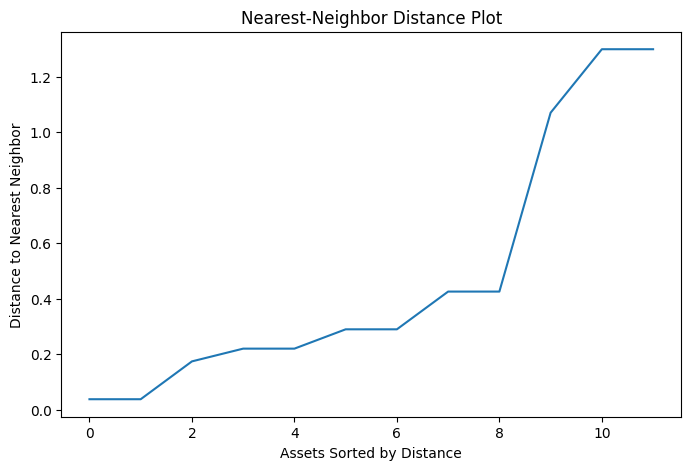

In [27]:
plt.figure(figsize=(8, 5))
plt.plot(sorted_distances)
plt.title("Nearest-Neighbor Distance Plot")
plt.xlabel("Assets Sorted by Distance")
plt.ylabel("Distance to Nearest Neighbor")
plt.show()

Look for a sharp bend in the curve.

The distance near the bend can be used as a starting value for `eps`.

# 28. Fit the Final DBSCAN Model

In [29]:
dbscan = DBSCAN(
    eps=0.8,
    min_samples=2
)

dbscan_labels = dbscan.fit_predict(
    scaled_features
)

clustered_assets["DBSCANCluster"] = dbscan_labels

clustered_assets

,AverageDailyReturn,DailyVolatility,AnnualizedReturn,AnnualizedVolatility,KMeansCluster,DBSCANCluster
Ticker,,,,,,
AAPL,0.001477,0.013451,0.372128,0.213524,0,0
AMZN,0.002061,0.019290,0.519251,0.306214,0,0
BAC,0.000664,0.015696,0.167295,0.249167,0,0
GOOG,0.001672,0.018376,0.421457,0.291708,0,0
JPM,0.001242,0.013977,0.312937,0.221885,0,0
KO,0.000012,0.008231,0.002992,0.130659,0,0
META,0.003367,0.024055,0.848523,0.381857,1,-1
MSFT,0.001230,0.014282,0.309952,0.226726,0,0
NVDA,0.004970,0.031805,1.252452,0.504883,1,-1


# 29. Count DBSCAN Clusters and Noise

In [30]:
number_of_dbscan_clusters = len(
    set(dbscan_labels) - {-1}
)

number_of_noise_assets = sum(
    dbscan_labels == -1
)

print(
    "DBSCAN clusters:",
    number_of_dbscan_clusters
)

print(
    "Noise assets:",
    number_of_noise_assets
)

DBSCAN clusters: 1
Noise assets: 3


# 30. Visualize DBSCAN Clusters

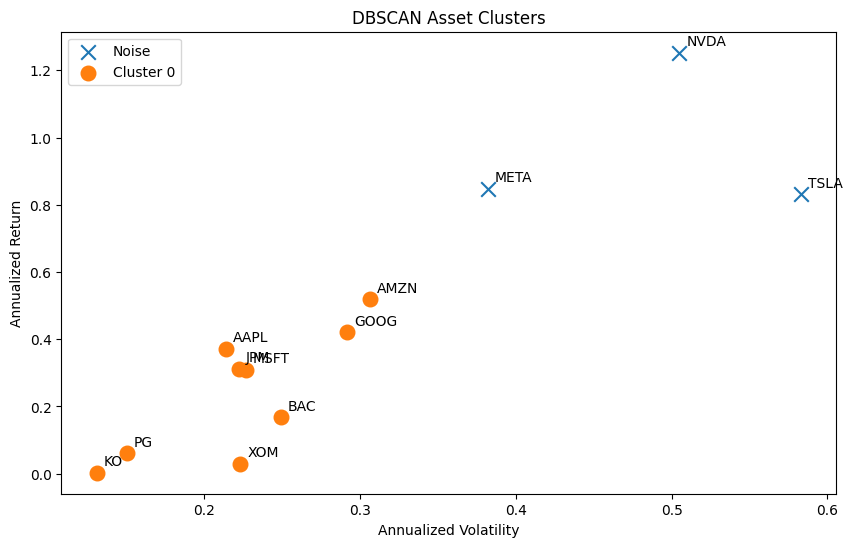

In [31]:
plt.figure(figsize=(10, 6))

for cluster_id in sorted(
    clustered_assets["DBSCANCluster"].unique()
):
    subset = clustered_assets[
        clustered_assets["DBSCANCluster"] == cluster_id
    ]

    if cluster_id == -1:
        label = "Noise"
        marker = "x"
    else:
        label = f"Cluster {cluster_id}"
        marker = "o"

    plt.scatter(
        subset["AnnualizedVolatility"],
        subset["AnnualizedReturn"],
        label=label,
        marker=marker,
        s=110
    )

for ticker, row in clustered_assets.iterrows():
    plt.annotate(
        ticker,
        (
            row["AnnualizedVolatility"],
            row["AnnualizedReturn"]
        ),
        xytext=(5, 5),
        textcoords="offset points"
    )

plt.title("DBSCAN Asset Clusters")
plt.xlabel("Annualized Volatility")
plt.ylabel("Annualized Return")
plt.legend()
plt.show()

# 31. Summarize DBSCAN Clusters

In [32]:
dbscan_non_noise = clustered_assets[
    clustered_assets["DBSCANCluster"] != -1
]

dbscan_summary = dbscan_non_noise.groupby(
    "DBSCANCluster"
)[[
    "AnnualizedReturn",
    "AnnualizedVolatility"
]].mean()

dbscan_summary["AssetCount"] = (
    dbscan_non_noise
    .groupby("DBSCANCluster")
    .size()
)

dbscan_summary

,AnnualizedReturn,AnnualizedVolatility,AssetCount
DBSCANCluster,,,
0,0.244202,0.223694,9


## Display Noise Assets

In [33]:
noise_assets = clustered_assets[
    clustered_assets["DBSCANCluster"] == -1
]

noise_assets

,AverageDailyReturn,DailyVolatility,AnnualizedReturn,AnnualizedVolatility,KMeansCluster,DBSCANCluster
Ticker,,,,,,
META,0.003367,0.024055,0.848523,0.381857,1,-1
NVDA,0.004970,0.031805,1.252452,0.504883,1,-1
TSLA,0.003297,0.036730,0.830916,0.583066,1,-1


# 32. Compare K-Means and DBSCAN

In [34]:
algorithm_comparison = clustered_assets[
    [
        "AnnualizedReturn",
        "AnnualizedVolatility",
        "KMeansCluster",
        "DBSCANCluster"
    ]
].copy()

algorithm_comparison

,AnnualizedReturn,AnnualizedVolatility,KMeansCluster,DBSCANCluster
Ticker,,,,
AAPL,0.372128,0.213524,0,0
AMZN,0.519251,0.306214,0,0
BAC,0.167295,0.249167,0,0
GOOG,0.421457,0.291708,0,0
JPM,0.312937,0.221885,0,0
KO,0.002992,0.130659,0,0
META,0.848523,0.381857,1,-1
MSFT,0.309952,0.226726,0,0
NVDA,1.252452,0.504883,1,-1


## K-Means vs DBSCAN

| Topic | K-Means | DBSCAN |
|---|---|---|
| Cluster definition | Distance from centroid | Density of nearby points |
| Number of clusters | Selected before training | Discovered automatically |
| Noise handling | Assigns every point | Can label noise as `-1` |
| Cluster shape | Prefers compact groups | Can identify irregular groups |
| Important parameters | `n_clusters` | `eps`, `min_samples` |
| Sensitive to scaling | Yes | Yes |
| Every asset assigned | Yes | No |

# 33. Visual Comparison

## K-Means Plot

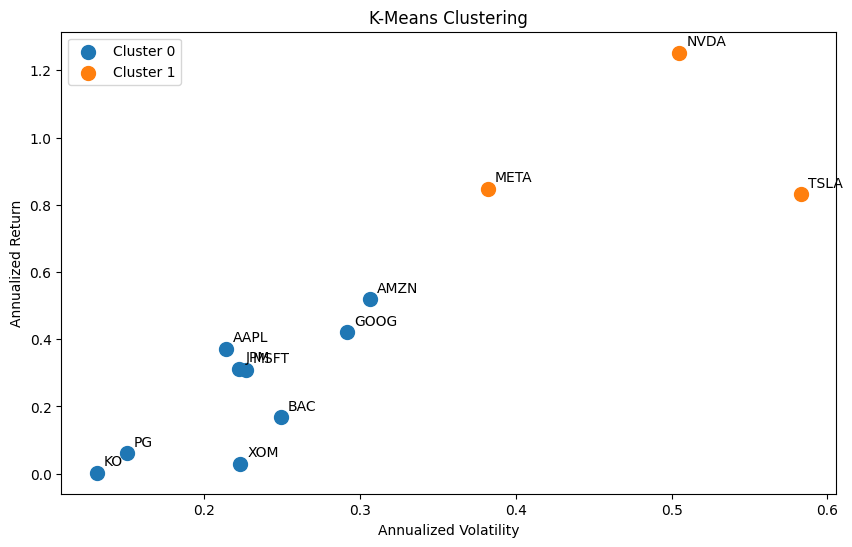

In [35]:
plt.figure(figsize=(10, 6))

for cluster_id in sorted(
    clustered_assets["KMeansCluster"].unique()
):
    subset = clustered_assets[
        clustered_assets["KMeansCluster"] == cluster_id
    ]

    plt.scatter(
        subset["AnnualizedVolatility"],
        subset["AnnualizedReturn"],
        label=f"Cluster {cluster_id}",
        s=100
    )

for ticker, row in clustered_assets.iterrows():
    plt.annotate(
        ticker,
        (
            row["AnnualizedVolatility"],
            row["AnnualizedReturn"]
        ),
        xytext=(5, 5),
        textcoords="offset points"
    )

plt.title("K-Means Clustering")
plt.xlabel("Annualized Volatility")
plt.ylabel("Annualized Return")
plt.legend()
plt.show()

## DBSCAN Plot

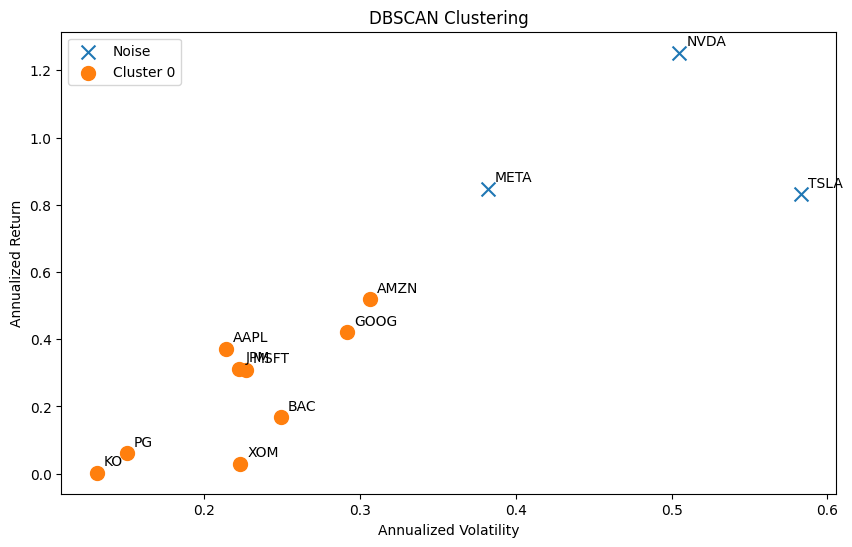

In [36]:
plt.figure(figsize=(10, 6))

for cluster_id in sorted(
    clustered_assets["DBSCANCluster"].unique()
):
    subset = clustered_assets[
        clustered_assets["DBSCANCluster"] == cluster_id
    ]

    marker = "x" if cluster_id == -1 else "o"
    label = (
        "Noise"
        if cluster_id == -1
        else f"Cluster {cluster_id}"
    )

    plt.scatter(
        subset["AnnualizedVolatility"],
        subset["AnnualizedReturn"],
        label=label,
        marker=marker,
        s=100
    )

for ticker, row in clustered_assets.iterrows():
    plt.annotate(
        ticker,
        (
            row["AnnualizedVolatility"],
            row["AnnualizedReturn"]
        ),
        xytext=(5, 5),
        textcoords="offset points"
    )

plt.title("DBSCAN Clustering")
plt.xlabel("Annualized Volatility")
plt.ylabel("Annualized Return")
plt.legend()
plt.show()

# 34. Find Similar Assets

## Same K-Means Cluster

In [37]:
selected_ticker = "AAPL"

selected_cluster = clustered_assets.loc[
    selected_ticker,
    "KMeansCluster"
]

same_cluster_assets = clustered_assets[
    clustered_assets["KMeansCluster"] == selected_cluster
].drop(index=selected_ticker)

same_cluster_assets

,AverageDailyReturn,DailyVolatility,AnnualizedReturn,AnnualizedVolatility,KMeansCluster,DBSCANCluster
Ticker,,,,,,
AMZN,0.002061,0.019290,0.519251,0.306214,0,0
BAC,0.000664,0.015696,0.167295,0.249167,0,0
GOOG,0.001672,0.018376,0.421457,0.291708,0,0
JPM,0.001242,0.013977,0.312937,0.221885,0,0
KO,0.000012,0.008231,0.002992,0.130659,0,0
MSFT,0.001230,0.014282,0.309952,0.226726,0,0
PG,0.000246,0.009466,0.062000,0.150265,0,0
XOM,0.000118,0.014054,0.029804,0.223099,0,0


## Distance-Based Similarity

In [38]:
distance_matrix = pd.DataFrame(
    pairwise_distances(scaled_features_df),
    index=scaled_features_df.index,
    columns=scaled_features_df.index
)

distance_matrix["AAPL"].sort_values().head(5)

,AAPL
Ticker,
AAPL,1.053671e-08
JPM,1.742541e-01
MSFT,1.978779e-01
GOOG,6.113969e-01
BAC,6.235598e-01


This gives a more precise similarity ranking than cluster membership alone.

# 35. Interpret the Results

## K-Means Interpretation

```text
K-Means created ___ clusters.

Cluster 0:
- Return:
- Volatility:
- Interpretation:

Cluster 1:
- Return:
- Volatility:
- Interpretation:

Cluster 2:
- Return:
- Volatility:
- Interpretation:
```

## DBSCAN Interpretation

```text
DBSCAN discovered ___ clusters.

Noise assets:
...

Cluster 0:
...

Cluster 1:
...
```

## Algorithm Comparison

```text
K-Means assigned every asset to a cluster.

DBSCAN allowed unusual assets to remain unassigned as noise.

For this dataset, ______ produced the more useful grouping because ______.
```

# 36. Limitations

## Historical Dependence

Clusters depend on the chosen date range.

## Feature Dependence

Using only return and volatility ignores:

- Sector.
- Market capitalization.
- Dividends.
- Drawdown.
- Correlation.
- Valuation.
- Sentiment.

## Algorithm Assumptions

K-Means prefers compact groups.

DBSCAN is sensitive to `eps` and `min_samples`.

## No Future Guarantee

Historical similarity does not guarantee future similarity.

## Not Investment Advice

These results are educational and should not be treated as buy or sell recommendations.

# 37. Final Cluster Report

In [39]:
final_cluster_report = clustered_assets[
    [
        "AverageDailyReturn",
        "DailyVolatility",
        "AnnualizedReturn",
        "AnnualizedVolatility",
        "KMeansCluster",
        "DBSCANCluster"
    ]
].copy()

final_cluster_report

,AverageDailyReturn,DailyVolatility,AnnualizedReturn,AnnualizedVolatility,KMeansCluster,DBSCANCluster
Ticker,,,,,,
AAPL,0.001477,0.013451,0.372128,0.213524,0,0
AMZN,0.002061,0.019290,0.519251,0.306214,0,0
BAC,0.000664,0.015696,0.167295,0.249167,0,0
GOOG,0.001672,0.018376,0.421457,0.291708,0,0
JPM,0.001242,0.013977,0.312937,0.221885,0,0
KO,0.000012,0.008231,0.002992,0.130659,0,0
META,0.003367,0.024055,0.848523,0.381857,1,-1
MSFT,0.001230,0.014282,0.309952,0.226726,0,0
NVDA,0.004970,0.031805,1.252452,0.504883,1,-1


# 38. Interpretation Write-Up Template

## Objective

The objective was to group financial assets based on historical return and volatility.

## Features

The clustering models used:

- Annualized return.
- Annualized volatility.

## Preprocessing

The features were standardized because both K-Means and DBSCAN use distance.

## K-Means Result

```text
K-Means created ___ clusters.

Cluster 0:
...

Cluster 1:
...

Cluster 2:
...
```

## DBSCAN Result

```text
DBSCAN discovered ___ clusters and identified ___ assets as noise.

Noise assets:
...
```

## Comparison

```text
K-Means was useful because every asset received a cluster label.

DBSCAN was useful because it identified assets with unusual risk-return
profiles.

For this dataset, ______ was more useful because ______.
```

## Limitations

```text
The results depend on the selected assets, date range, engineered features,
scaling method, and clustering parameters.
```

# 39. Final Assignment

Choose at least ten stocks or ETFs.

## Requirements

1. Download historical prices.
2. Inspect and clean the data.
3. Calculate daily returns.
4. Engineer average return and volatility.
5. Annualize return and volatility.
6. Create one row per asset.
7. Standardize the features.
8. Use the elbow method.
9. Calculate silhouette scores.
10. Fit K-Means.
11. Visualize K-Means clusters.
12. Display K-Means centroids.
13. Explain `eps` and `min_samples`.
14. Test multiple DBSCAN parameter combinations.
15. Use a nearest-neighbor distance plot.
16. Fit DBSCAN.
17. Visualize DBSCAN clusters and noise.
18. Compare K-Means and DBSCAN labels.
19. Create a final cluster report.
20. Write three to five observations.

## Expected Committed Output

The committed notebook should include:

- Engineered feature table.
- Scaling step.
- Elbow plot.
- Silhouette table.
- K-Means labels and visualization.
- DBSCAN labels and visualization.
- Noise assets.
- Algorithm comparison table.
- Short interpretation write-up.

# 40. Review Questions

1. What is unsupervised learning?
2. What is clustering?
3. What is a feature?
4. Why use return and volatility?
5. Why avoid raw price?
6. Why scale features?
7. What is a centroid?
8. What does `K` mean?
9. What is inertia?
10. What is the elbow method?
11. What is silhouette score?
12. What does DBSCAN stand for?
13. What is a core point?
14. What is a border point?
15. What is a noise point?
16. What does `eps` control?
17. What does `min_samples` control?
18. Why does DBSCAN use label `-1`?
19. Why might K-Means and DBSCAN disagree?
20. Which algorithm is better for identifying unusual assets?

# 41. Key Takeaways

- Unsupervised learning discovers structure without labels.
- Clustering groups similar assets.
- Return and volatility create a simple risk-return representation.
- Feature scaling is essential for distance-based methods.
- K-Means creates a fixed number of centroid-based clusters.
- DBSCAN discovers dense groups and can identify noise.
- The elbow method and silhouette score help select K-Means parameters.
- DBSCAN depends heavily on `eps` and `min_samples`.
- Cluster labels are arbitrary and require interpretation.
- Different algorithms may produce different but valid views of the same data.
- Clusters summarize historical similarity, not future performance.